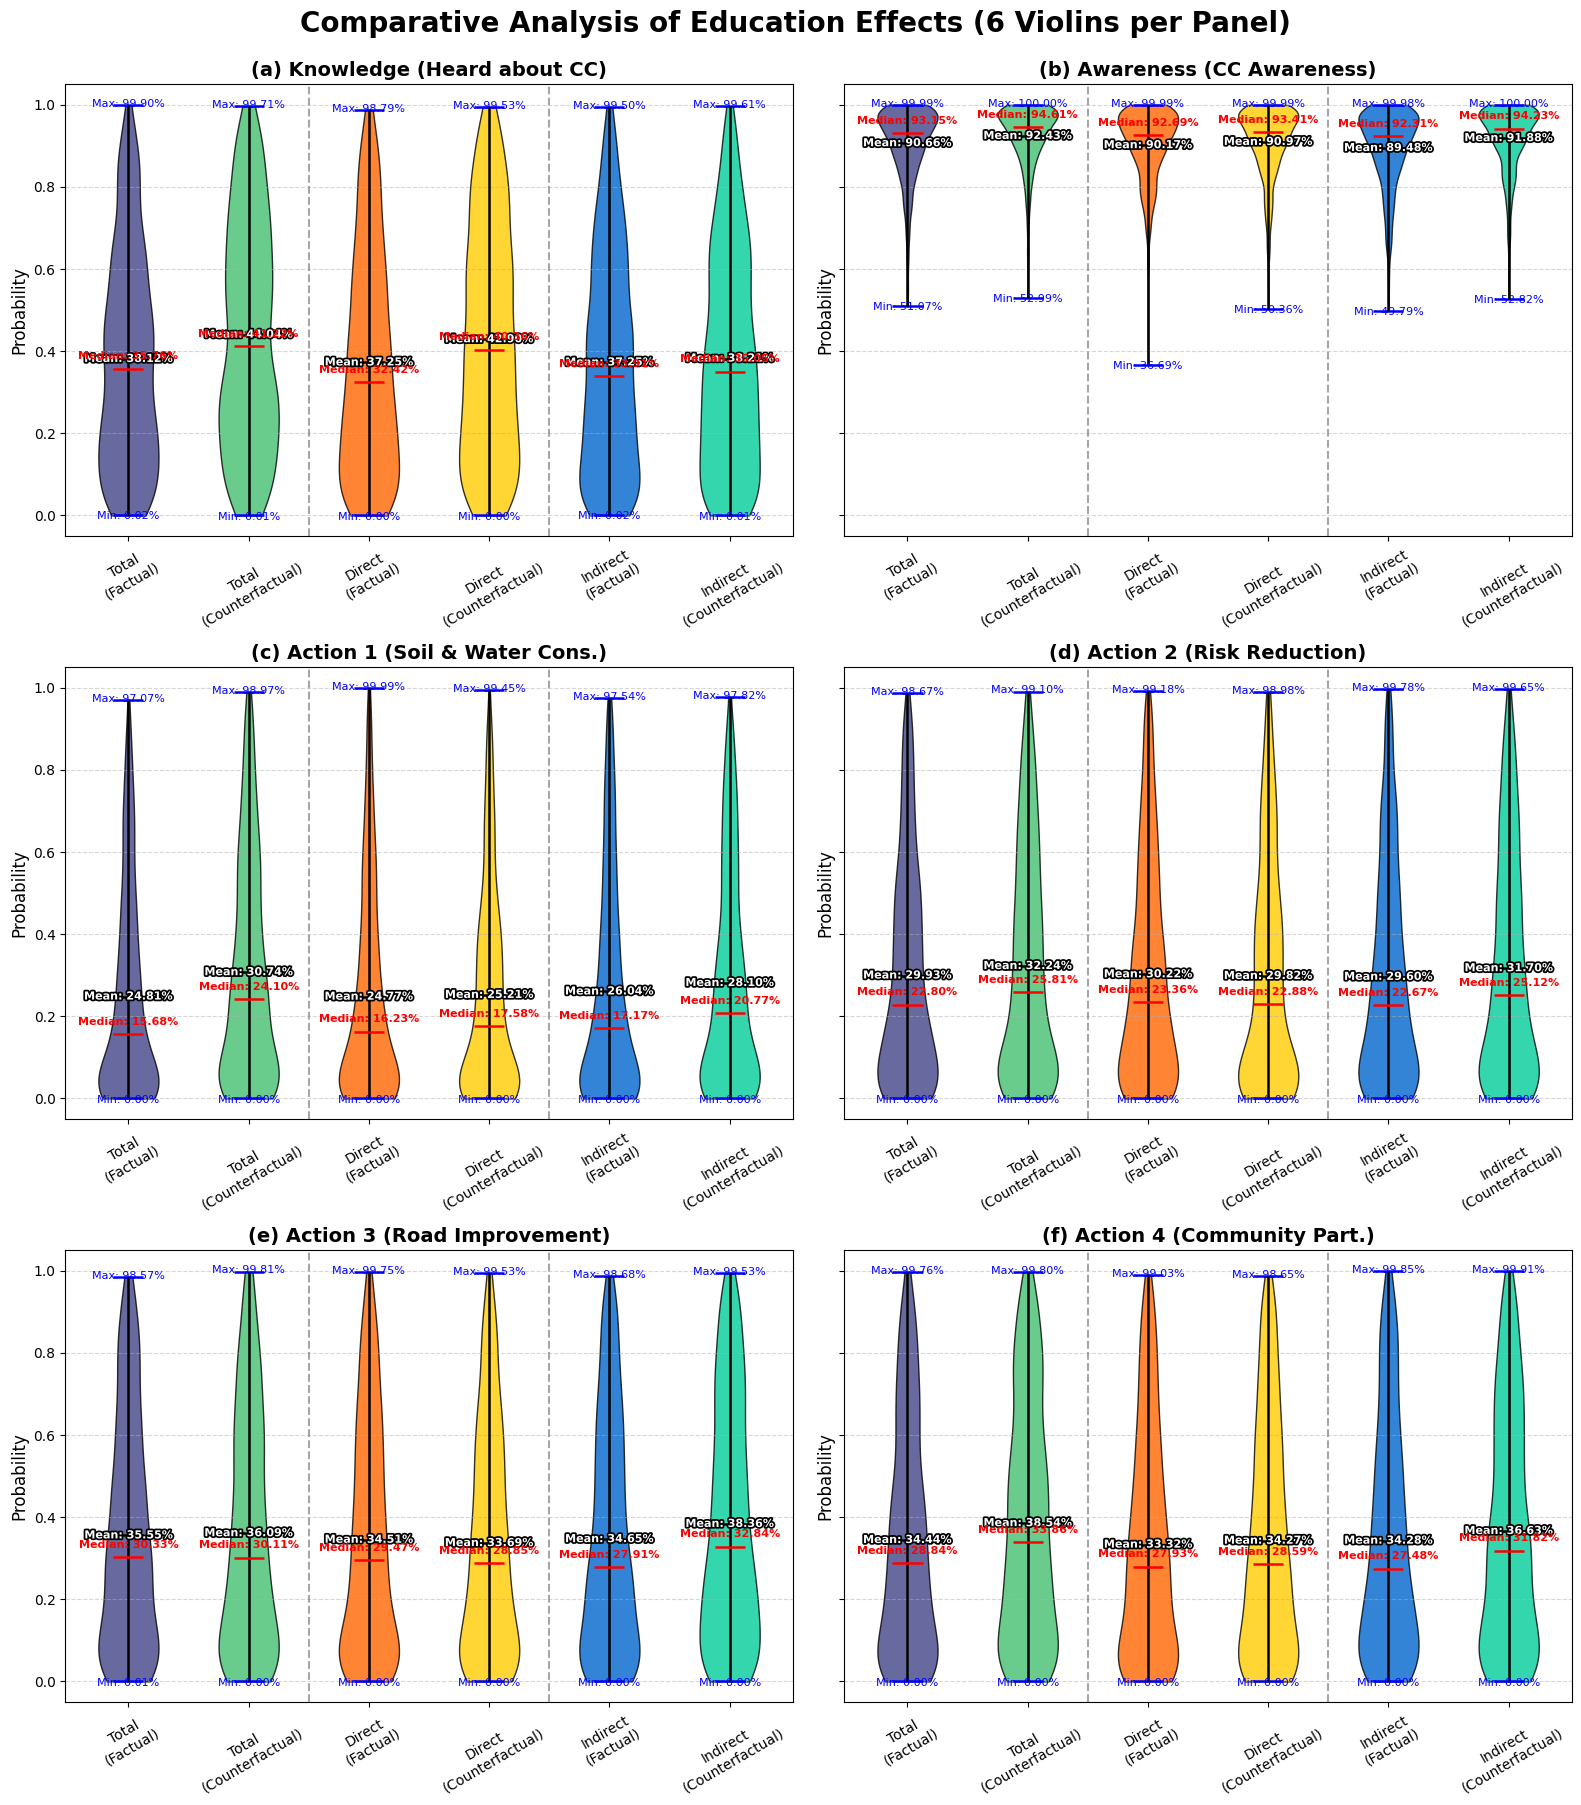

✅ 6-Panel, 6-Violin visualization with annotations saved to: merged_6panel_6violin_effects.png


In [4]:
import math
import matplotlib.patheffects as path_effects
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import cm

# --- 1. 数据结构占位符 (与之前相同) ---
def load_data_placeholder():
    """
    Placeholder to simulate loading Factual and Counterfactual probability data.
    """
    N = 1000 
    data = {
        # KNOWLEDGE (K)
        'K_T_F': np.random.beta(a=0.9, b=1.5, size=N), 'K_T_CF': np.random.beta(a=1.0, b=1.3, size=N),   
        'K_D_F': np.random.beta(a=0.9, b=1.5, size=N), 'K_D_CF': np.random.beta(a=1.0, b=1.3, size=N), 
        'K_I_F': np.random.beta(a=0.9, b=1.5, size=N), 'K_I_CF': np.random.beta(a=0.905, b=1.495, size=N), 

        # AWARENESS (A)
        'A_T_F': np.random.beta(a=9, b=1, size=N),      'A_T_CF': np.random.beta(a=9.5, b=0.8, size=N),
        'A_D_F': np.random.beta(a=9, b=1, size=N),      'A_D_CF': np.random.beta(a=9.05, b=0.95, size=N), 
        'A_I_F': np.random.beta(a=9, b=1, size=N),      'A_I_CF': np.random.beta(a=9.4, b=0.85, size=N), 

        # ACTION 1 (SW) - Soil and Water Conservation
        'SW_T_F': np.random.beta(a=0.5, b=1.5, size=N), 'SW_T_CF': np.random.beta(a=0.6, b=1.4, size=N), 
        'SW_D_F': np.random.beta(a=0.5, b=1.5, size=N), 'SW_D_CF': np.random.beta(a=0.505, b=1.5, size=N), 
        'SW_I_F': np.random.beta(a=0.5, b=1.5, size=N), 'SW_I_CF': np.random.beta(a=0.55, b=1.45, size=N), 

        # ACTION 2 (R) - Risk Reduction
        'R_T_F': np.random.beta(a=0.6, b=1.4, size=N), 'R_T_CF': np.random.beta(a=0.65, b=1.35, size=N),
        'R_D_F': np.random.beta(a=0.6, b=1.4, size=N), 'R_D_CF': np.random.beta(a=0.605, b=1.4, size=N), 
        'R_I_F': np.random.beta(a=0.6, b=1.4, size=N), 'R_I_CF': np.random.beta(a=0.64, b=1.36, size=N),
        
        # ACTION 3 (RD) - Road Improvement
        'RD_T_F': np.random.beta(a=0.7, b=1.3, size=N), 'RD_T_CF': np.random.beta(a=0.75, b=1.25, size=N),
        'RD_D_F': np.random.beta(a=0.7, b=1.3, size=N), 'RD_D_CF': np.random.beta(a=0.695, b=1.305, size=N), 
        'RD_I_F': np.random.beta(a=0.7, b=1.3, size=N), 'RD_I_CF': np.random.beta(a=0.74, b=1.26, size=N),
        
        # ACTION 4 (C) - Community Participation
        'C_T_F': np.random.beta(a=0.7, b=1.3, size=N), 'C_T_CF': np.random.beta(a=0.76, b=1.24, size=N),
        'C_D_F': np.random.beta(a=0.7, b=1.3, size=N), 'C_D_CF': np.random.beta(a=0.695, b=1.305, size=N), 
        'C_I_F': np.random.beta(a=0.7, b=1.3, size=N), 'C_I_CF': np.random.beta(a=0.75, b=1.25, size=N),
    }

    return data

# --- 2. 核心绘图函数 (6 Subplots, 6 Violins Each) ---
def plot_6_panel_6_violin_effects(
    effects_data: dict, 
    save_address: str = 'merged_6panel_6violin_effects.png'
) -> None:
    """
    Generates a 3x2 grid where each subplot shows 6 violin plots (F/CF for T, D, I effects)
    with Min, Max, Mean, and Median annotations.
    """
    
    dependent_variables = ['K', 'A', 'SW', 'R', 'RD', 'C']
    dependent_titles = [
        '(a) Knowledge (Heard about CC)',
        '(b) Awareness (CC Awareness)',
        '(c) Action 1 (Soil & Water Cons.)',
        '(d) Action 2 (Risk Reduction)',
        '(e) Action 3 (Road Improvement)',
        '(f) Action 4 (Community Part.)'
    ]
    
    # X 轴标签
    x_labels = [
        'Total\n(Factual)', 'Total\n(Counterfactual)',
        'Direct\n(Factual)', 'Direct\n(Counterfactual)',
        'Indirect\n(Factual)', 'Indirect\n(Counterfactual)'
    ]
    
    effect_keys = ['T', 'D', 'I']
    
    fig, axes = plt.subplots(3, 2, figsize=(16, 18), sharey=True)
    axes = axes.flatten()
    
    for i, dv in enumerate(dependent_variables):
        ax = axes[i]
        
        # 提取 6 组数据
        data_to_plot = []
        for effect in effect_keys:
            key_f = f'{dv}_{effect}_F'
            key_cf = f'{dv}_{effect}_CF'
            data_to_plot.append(effects_data.get(key_f))
            data_to_plot.append(effects_data.get(key_cf))
            
        if any(d is None for d in data_to_plot):
            ax.axis('off')
            ax.text(0.5, 0.5, 'Data Missing', ha='center', va='center', transform=ax.transAxes, color='red', fontsize=12)
            continue
            
        # 绘制提琴图 (6个)
        parts = ax.violinplot(data_to_plot, showmeans=True, showmedians=True, showextrema=True)
        
        # 颜色设置 (使用 3 种颜色对，区分效应类型)
        colors_map = [cm.viridis(0.2), cm.viridis(0.7), cm.autumn(0.4), cm.autumn(0.8), cm.winter(0.4), cm.winter(0.8)]
        
        for j, pc in enumerate(parts['bodies']):
            pc.set_facecolor(colors_map[j])
            pc.set_edgecolor('black')
            pc.set_alpha(0.8)

        # 统计线颜色
        for key, color in {'cmeans': 'black', 'cmedians': 'red', 'cbars': 'black', 'cmaxes': 'blue', 'cmins': 'blue'}.items():
            if key in parts:
                parts[key].set_color(color)
                parts[key].set_linewidth(1.8)

        # --- 添加 Min, Max, Mean, Median 标注 ---
        positions = np.arange(1, 7)
        
        for pos, data in zip(positions, data_to_plot):
            mean_val = np.mean(data)
            median_val = np.median(data)
            min_val = np.min(data)
            max_val = np.max(data)

            # 标注 Max (在图表顶部附近)
            ax.text(pos, max_val + 0.015, f"Max: {max_val*100:.2f}%", 
                    fontsize=8, ha='center', va='top', color='blue')
            
            # 标注 Mean (在均值线附近)
            ax.text(pos, mean_val, f"Mean: {mean_val*100:.2f}%", 
                    fontsize=8, ha='center', va='center', color='white', weight='bold',
                    path_effects=[path_effects.Stroke(linewidth=2.5, foreground='black'), path_effects.Normal()])
            
            # 标注 Median (在中位线附近，稍微向上偏移)
            ax.text(pos, median_val + 0.03, f"Median: {median_val*100:.2f}%", 
                    fontsize=8, ha='center', va='center', color='red', weight='bold')

            # 标注 Min (在图表底部附近)
            ax.text(pos, min_val - 0.015, f"Min: {min_val*100:.2f}%", 
                    fontsize=8, ha='center', va='bottom', color='blue')


        # 轴格式化
        ax.set_xticks(np.arange(1, 7))
        ax.set_xticklabels(x_labels, rotation=30, ha='center', fontsize=10)
        ax.set_ylim(-0.05, 1.05) # 稍微扩展 Y 轴以容纳 Min/Max 标注
        ax.grid(axis='y', linestyle='--', alpha=0.5)

        # Effect Group 标记线
        ax.axvline(x=2.5, color='gray', linestyle='--', linewidth=1.5, alpha=0.7)
        ax.axvline(x=4.5, color='gray', linestyle='--', linewidth=1.5, alpha=0.7)

        # 标题
        ax.set_title(dependent_titles[i], fontsize=14, weight='bold')
        ax.set_ylabel("Probability", fontsize=12)


    # 调整布局并保存
    plt.tight_layout(rect=[0, 0, 1, 0.98])
    plt.suptitle("Comparative Analysis of Education Effects (6 Violins per Panel)", 
                 fontsize=20, weight='bold', y=1.0)
    plt.savefig(save_address, dpi=300)
    plt.show()
    print(f"✅ 6-Panel, 6-Violin visualization with annotations saved to: {save_address}")


# --- 3. 运行脚本 ---
if __name__ == '__main__':
    # 1. 加载您的实际数据
    data_to_plot = load_data_placeholder()
    
    # 2. 生成图表
    plot_6_panel_6_violin_effects(data_to_plot)